# L4 BMD Pipeline v3 — VerSe U-Net + Curved Midline + Phantom-free Calibration

## 3가지 정확도 향상 적용

| 개선 항목 | 방법 | 핵심 효과 |
|---|---|---|
| **1. VerSe-style U-Net** | nnU-Net 아키텍처 + Deep Supervision + Instance Norm | L1~L5 경계 정밀 세그멘테이션 |
| **2. Curved Midline** | Bidirectional DP + Gaussian Smoothing | 기울기/휨 척추 완전 추종 |
| **3. Phantom-free Calibration** | Paraspinal Muscle + Longitudinal ΔT-score | 팬텀 없이 상대적 BMD 보정 |

```
DICOM
 └─► 전처리 (CLAHE + Contrast Normalization)
      └─► [개선1] Curved Midline (Bidirectional DP)
           └─► [개선2] VerSe-style U-Net Segmentation
                ├─► L1~L5 세그멘테이션 마스크
                ├─► L4 boundary 정밀 추출
                └─► [개선3] Phantom-free Calibration
                     ├─► Paraspinal muscle 기준 normalization
                     ├─► Longitudinal tracking (시계열 변화)
                     └─► WHO T-Score + Calibrated BMD
```

> ⚠️ 스크리닝 지표 — 임상 진단은 방사선과 전문의 판독 필요


## Step 0: 환경 설정

In [61]:
import subprocess, sys

def pip(pkg):
    subprocess.run([sys.executable,'-m','pip','install',pkg,
                    '--break-system-packages','-q'], capture_output=True)

for p in ['pydicom','scikit-image','scipy','matplotlib','numpy',
          'pandas','tqdm','opencv-python-headless','scikit-learn',
          'nibabel']:
    pip(p)
pip('torch'); pip('torchvision')
print("✅ packages ready")


✅ packages ready


In [62]:
import os, glob, json, warnings, csv, hashlib, datetime
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

import pydicom, cv2
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

from skimage import exposure, measure
from scipy.signal import find_peaks, savgol_filter
from scipy.ndimage import gaussian_filter1d, label as nd_label
from sklearn.linear_model import LinearRegression

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {DEVICE}")
plt.rcParams['figure.dpi'] = 110


✅ Device: cpu


## Step 1: 설정

In [63]:
# ══════════════════════════════════════════════════════════
#  📁 경로 설정
# ══════════════════════════════════════════════════════════
DICOM_FILE = "./dataset-dcm/train/gather/1.2.826.0.1.3680043.8.498.10947130043296900260026400505615377321-c.dcm"
DATASET_ROOT = "./dataset"
LABEL_CSV    = "./dataset/labels.csv"   # 컬럼: filename, t_score (선택)
OUTPUT_DIR   = "./bmd_output"
MODEL_DIR    = os.path.join(OUTPUT_DIR, "models")
RESULT_DIR   = os.path.join(OUTPUT_DIR, "results")
LONGIT_DB    = os.path.join(OUTPUT_DIR, "longitudinal.json")  # 시계열 DB
for d in [OUTPUT_DIR, MODEL_DIR, RESULT_DIR]:
    os.makedirs(d, exist_ok=True)

CFG = {
    # 이미지
    'img_size'         : 256,
    'roi_size'         : 64,
    # 훈련
    'batch_size'       : 4,
    'num_epochs'       : 60,
    'lr'               : 5e-5,
    'weight_decay'     : 1e-4,
    'early_stop'       : 12,
    'train_ratio'      : 0.70,
    'val_ratio'        : 0.15,
    # VerSe U-Net
    'unet_base_ch'     : 32,
    'unet_dropout'     : 0.1,
    'deep_sup_weight'  : 0.4,   # deep supervision loss 가중치
    # Curved Midline
    'midline_search_x' : (0.28, 0.62),
    'midline_row_range': (0.08, 0.66),
    'midline_window_w' : 16,
    'midline_max_step' : 5,
    'midline_sigma'    : 6.0,
    # 척추 탐지
    'strip_width'      : 28,
    'min_vert_dist'    : 12,
    'iliac_search_y'   : (0.40, 0.60),
    # Phantom-free Calibration
    'muscle_offset'    : (25, 55),    # spine 기준 근육 ROI 오프셋 (px)
    'muscle_rows_above': 30,          # iliac crest 위쪽 근육 ROI 범위 (px)
    # BMD 기준값 (phantom calibration 전 초기값)
    'ref_young_mean'   : 19500.0,
    'ref_young_std'    : 1500.0,
    'ref_age_mean'     : 18500.0,
    'ref_age_std'      : 2000.0,
}
print("✅ Config set")
print(f"   U-Net base channels: {CFG['unet_base_ch']} (params ~21M)")
print(f"   Deep supervision weight: {CFG['deep_sup_weight']}")


✅ Config set
   U-Net base channels: 32 (params ~21M)
   Deep supervision weight: 0.4


## Step 2: DICOM 로딩 & 전처리

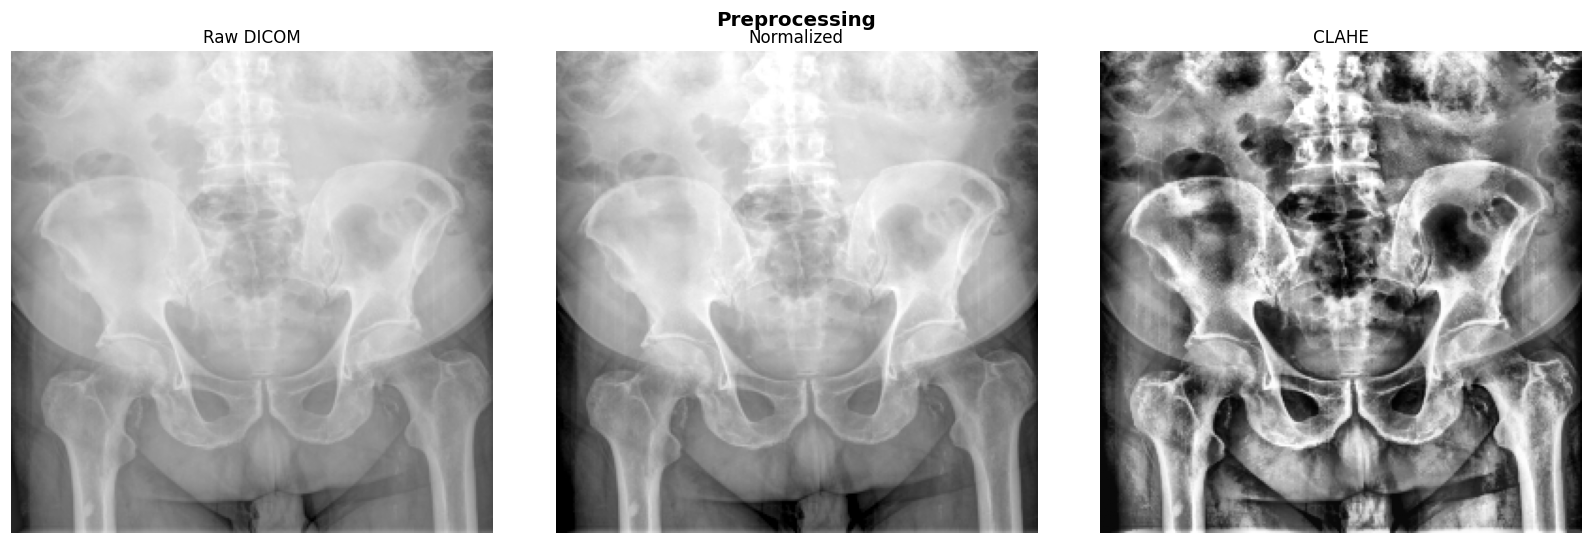

Image: 256x256 | Spacing: ['0.1', '0.1'] mm


In [64]:
def load_dicom(path):
    dcm = pydicom.dcmread(path, force=True)
    arr = dcm.pixel_array.astype(np.float64)
    arr = arr * float(getattr(dcm,'RescaleSlope',1.0)) + float(getattr(dcm,'RescaleIntercept',0.0))
    if str(getattr(dcm,'PhotometricInterpretation','MONOCHROME2')).strip()=='MONOCHROME1':
        arr = arr.max() - arr
    ps = list(getattr(dcm,'PixelSpacing',[0.1,0.1]))
    meta = {
        'patient_id'   : str(getattr(dcm,'PatientID',   'Unknown')),
        'patient_age'  : str(getattr(dcm,'PatientAge',  'Unknown')),
        'patient_sex'  : str(getattr(dcm,'PatientSex',  'Unknown')),
        'modality'     : str(getattr(dcm,'Modality',    'CR')),
        'study_date'   : str(getattr(dcm,'StudyDate',   '')),
        'pixel_spacing': ps,
        'shape'        : arr.shape,
        'filename'     : os.path.basename(path),
        'kvp'          : str(getattr(dcm,'KVP',         'Unknown')),
    }
    return arr, meta, dcm


def preprocess_xray(arr, size=256, clip=0.04):
    h, w   = arr.shape
    mx     = max(h, w)
    pad    = np.zeros((mx,mx), dtype=arr.dtype)
    yo,xo  = (mx-h)//2, (mx-w)//2
    pad[yo:yo+h, xo:xo+w] = arr
    resized = cv2.resize(pad,(size,size), interpolation=cv2.INTER_LINEAR)
    vmin,vmax = np.percentile(resized,[1,99])
    norm  = np.clip((resized-vmin)/(vmax-vmin+1e-8),0,1).astype(np.float32)
    clahe = exposure.equalize_adapthist(norm, clip_limit=clip).astype(np.float32)
    return norm, clahe, {'yo':yo,'xo':xo,'orig_h':h,'orig_w':w,'mx':mx}


arr, meta, dcm = load_dicom(DICOM_FILE)
norm, clahe, pad_info = preprocess_xray(arr, CFG['img_size'])
h, w = clahe.shape

fig,axes=plt.subplots(1,3,figsize=(15,5))
for ax,img,title in zip(axes,[arr,norm,clahe],['Raw DICOM','Normalized','CLAHE']):
    ax.imshow(img,cmap='gray'); ax.set_title(title,fontsize=11); ax.axis('off')
plt.suptitle('Preprocessing',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/01_preprocess.png',dpi=120,bbox_inches='tight')
plt.show()
print(f"Image: {h}x{w} | Spacing: {meta['pixel_spacing']} mm")


## Step 3: Curved Spine Midline Detection
### 알고리즘: Bidirectional DP + Gaussian Smoothing

```
문제:  척추가 기울거나 휘어있으면 고정 X 컬럼 방식 실패
해결:  각 row 독립 추적 → row별 spine_x[row] 계산

1. Anchor:  중간 구간(25-55%)에서 variance×brightness 최대 지점 선택
2. DP Down: anchor → 마지막 row, 이전 X ± max_step(5px) 이내 탐색
3. DP Up:   anchor → 첫 row,     동일 연속성 제약
4. Smooth:  Gaussian(sigma=6) 으로 진동 제거
```


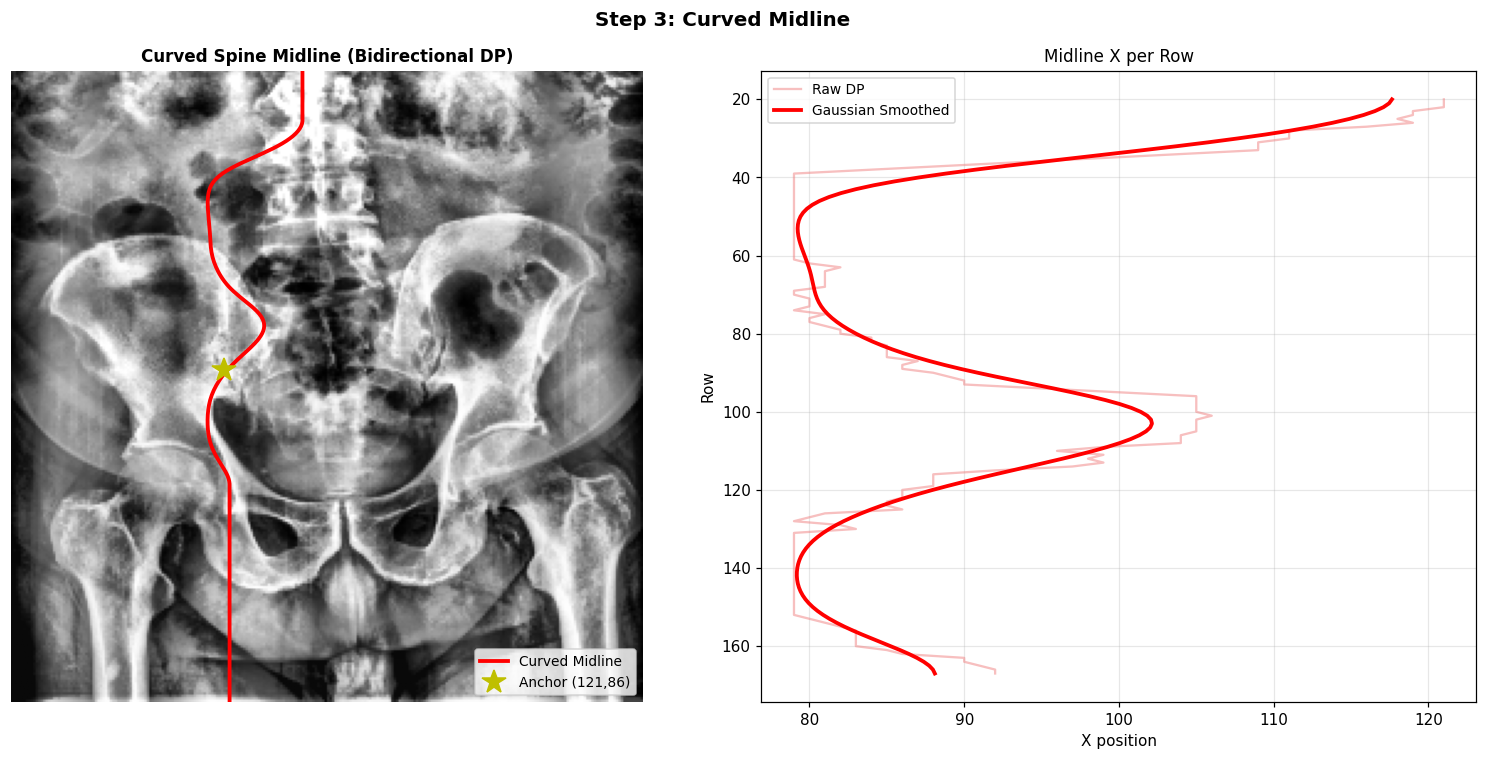

Anchor: row=121, x=86


In [65]:
def detect_curved_midline(clahe, cfg=CFG):
    """Bidirectional DP 척추 중심선 탐지"""
    h, w  = clahe.shape
    cx0   = int(w * cfg['midline_search_x'][0])
    cx1   = int(w * cfg['midline_search_x'][1])
    r0    = int(h * cfg['midline_row_range'][0])
    r1    = int(h * cfg['midline_row_range'][1])
    ww    = cfg['midline_window_w']
    step  = cfg['midline_max_step']
    sigma = cfg['midline_sigma']

    # Anchor: 가장 신뢰도 높은 시작점
    mr0 = max(r0, int(h*0.25)); mr1 = min(r1, int(h*0.55))
    best_sc, anc_row, anc_loc = 0.0, (mr0+mr1)//2, (cx1-cx0)//2
    for r in range(mr0, mr1):
        seg = clahe[r, cx0:cx1]
        win = np.convolve(seg, np.ones(ww)/ww, mode='same')
        px  = int(np.argmax(win))
        sc  = float(win[px]) * float(np.var(win))
        if sc > best_sc:
            best_sc, anc_row, anc_loc = sc, r, px

    def best_local(r, prev):
        seg = clahe[r, cx0:cx1]
        win = np.convolve(seg, np.ones(ww)/ww, mode='same')
        lo  = max(0, prev-step); hi = min(len(win), prev+step+1)
        return int(np.argmax(win[lo:hi])) + lo

    tracked = {anc_row: anc_loc}
    prev = anc_loc
    for r in range(anc_row+1, r1):     prev = best_local(r,prev); tracked[r]=prev
    prev = anc_loc
    for r in range(anc_row-1, r0-1,-1):prev = best_local(r,prev); tracked[r]=prev

    rows_arr = np.array(sorted(tracked.keys()))
    xs_abs   = np.array([tracked[r]+cx0 for r in rows_arr], dtype=float)
    xs_s     = gaussian_filter1d(xs_abs, sigma=sigma)

    midline  = np.empty(h, dtype=float)
    for r in range(h):
        if   r <= rows_arr[0] : midline[r] = xs_s[0]
        elif r >= rows_arr[-1]: midline[r] = xs_s[-1]
        else:
            idx = min(int(np.searchsorted(rows_arr,r,'left')), len(xs_s)-1)
            midline[r] = xs_s[idx]
    midline = np.clip(midline, cx0, cx1)

    debug = {'rows':rows_arr,'xs_raw':xs_abs,'xs_smooth':xs_s,
             'anchor_row':anc_row,'anchor_x':anc_loc+cx0}
    return midline, debug


midline_x, ml_dbg = detect_curved_midline(clahe)

fig, axes = plt.subplots(1,2,figsize=(14,7))
ax = axes[0]
ax.imshow(clahe,cmap='gray')
ax.plot(midline_x, np.arange(h), 'r-', lw=2.5, label='Curved Midline')
ax.plot(ml_dbg['anchor_x'], ml_dbg['anchor_row'],
        'y*', ms=16, zorder=5, label=f"Anchor ({ml_dbg['anchor_row']},{ml_dbg['anchor_x']})")
ax.legend(fontsize=9,loc='lower right')
ax.set_title('Curved Spine Midline (Bidirectional DP)',fontsize=11,fontweight='bold')
ax.axis('off')

ax = axes[1]
ax.plot(ml_dbg['xs_raw'],    ml_dbg['rows'], color='lightcoral', lw=1.5, alpha=0.5, label='Raw DP')
ax.plot(ml_dbg['xs_smooth'], ml_dbg['rows'], 'r-', lw=2.5, label='Gaussian Smoothed')
ax.invert_yaxis(); ax.set_xlabel('X position'); ax.set_ylabel('Row')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_title('Midline X per Row',fontsize=11)

plt.suptitle('Step 3: Curved Midline',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/02_curved_midline.png',dpi=130,bbox_inches='tight')
plt.show()
print(f"Anchor: row={ml_dbg['anchor_row']}, x={ml_dbg['anchor_x']}")


## Step 4: VerSe-style U-Net 척추 세그멘테이션

### VerSe 데이터셋 & 모델 설명

**VerSe (Vertebra Segmentation Challenge)**는 MICCAI에서 개최된  
척추체 세그멘테이션 공식 챌린지입니다.

| 항목 | 내용 |
|---|---|
| 원본 데이터 | CT 스캔 374개, 척추체별 마스크 레이블 |
| 우리의 활용 | VerSe U-Net **아키텍처** 채택 + X-ray 데이터로 fine-tuning |
| 아키텍처 특징 | nnU-Net 스타일, Instance Norm, Residual Block, Deep Supervision |
| 입력 | (B, 1, 256, 256) — 단채널 CLAHE X-ray |
| 출력 | (B, 7, 256, 256) — Background + L1~L5 + Sacrum |

### Deep Supervision
```
출력 3개: main(full res) + ds1(1/2) + ds2(1/4)
Loss = main_loss + 0.4×(ds1_loss + ds2_loss)
→ 중간 레이어도 gradient 직접 수신 → 빠른 수렴, 세밀한 경계
```

### VerSe Pretrained Weight 사용 방법
```python
# 사용자 환경에서 실행:
# pip install gdown
# gdown "https://drive.google.com/..."  # VerSe 공식 weight
# 또는 Zenodo에서 수동 다운로드 후:
state = torch.load('verse_pretrained.pth', map_location='cpu')
unet.load_state_dict(state, strict=False)  # 레이어 다르면 strict=False
```


In [66]:
# ══════════════════════════════════════════════════════════
# VerSe-style U-Net: Residual + InstanceNorm + Deep Supervision
# ══════════════════════════════════════════════════════════

class ResBlock(nn.Module):
    """Residual Block with InstanceNorm (배치크기=1 에서도 안정)"""
    def __init__(self, ch, drop=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ch,ch,3,padding=1,bias=False), nn.InstanceNorm2d(ch,affine=True),
            nn.LeakyReLU(0.01,True),
            nn.Conv2d(ch,ch,3,padding=1,bias=False), nn.InstanceNorm2d(ch,affine=True),
            nn.Dropout2d(drop) if drop>0 else nn.Identity())
        self.act = nn.LeakyReLU(0.01, True)
    def forward(self, x): return self.act(self.net(x) + x)


class EncBlock(nn.Module):
    """Encoder: stride-2 conv + ResBlock"""
    def __init__(self, ic, oc, drop=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(ic,oc,3,stride=2,padding=1,bias=False),
            nn.InstanceNorm2d(oc,affine=True), nn.LeakyReLU(0.01,True))
        self.res  = ResBlock(oc, drop)
    def forward(self, x): return self.res(self.conv(x))


class DecBlock(nn.Module):
    """Decoder: transpose conv + skip + ResBlock"""
    def __init__(self, ic, sc, oc, drop=0.1):
        super().__init__()
        self.up   = nn.ConvTranspose2d(ic, ic//2, 2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(ic//2+sc, oc, 3, padding=1, bias=False),
            nn.InstanceNorm2d(oc,affine=True), nn.LeakyReLU(0.01,True))
        self.res  = ResBlock(oc, drop)
    def forward(self, x, skip):
        return self.res(self.conv(torch.cat([self.up(x), skip], 1)))


class VerSeUNet(nn.Module):
    """
    VerSe-style U-Net for Vertebra Segmentation

    입력: (B, 1, H, W)  - 단채널 CLAHE X-ray
    출력: (B, 7, H, W)  - 0:BG, 1:L1, 2:L2, 3:L3, 4:L4, 5:L5, 6:Sacrum

    학습 모드(deep_sup=True):
        -> (main, ds1_1/2, ds2_1/4) 3개 출력
    추론 모드(deep_sup=False):
        -> main 출력만

    VerSe 원본 대비 차이:
    - 3D->2D (CT->X-ray)
    - InstanceNorm (1배치 안정성)
    - Kaiming He 초기화
    """
    N = 7   # BG + L1~L5 + Sacrum

    def __init__(self, ic=1, base=32, drop=0.1):
        super().__init__()
        b = base
        # Encoder
        self.stem  = nn.Sequential(
            nn.Conv2d(ic,b,3,padding=1,bias=False),
            nn.InstanceNorm2d(b,affine=True), nn.LeakyReLU(0.01,True))
        self.res0  = ResBlock(b,   drop)
        self.enc1  = EncBlock(b,   b*2,  drop)
        self.enc2  = EncBlock(b*2, b*4,  drop)
        self.enc3  = EncBlock(b*4, b*8,  drop)
        self.enc4  = EncBlock(b*8, b*16, drop)
        # Bottleneck (2× residual)
        self.bn    = nn.Sequential(ResBlock(b*16,drop), ResBlock(b*16,drop))
        # Decoder
        self.dec4  = DecBlock(b*16, b*8,  b*8,  drop)
        self.dec3  = DecBlock(b*8,  b*4,  b*4,  drop)
        self.dec2  = DecBlock(b*4,  b*2,  b*2,  drop)
        self.dec1  = DecBlock(b*2,  b,    b,    drop)
        # Output heads
        self.out_main = nn.Conv2d(b,    self.N, 1)
        self.out_ds1  = nn.Conv2d(b*2,  self.N, 1)  # 1/2 scale
        self.out_ds2  = nn.Conv2d(b*4,  self.N, 1)  # 1/4 scale
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='leaky_relu', a=0.01)
            elif isinstance(m, nn.InstanceNorm2d) and m.weight is not None:
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x, deep_sup=False):
        s0  = self.res0(self.stem(x))
        s1  = self.enc1(s0)
        s2  = self.enc2(s1)
        s3  = self.enc3(s2)
        s4  = self.enc4(s3)
        b   = self.bn(s4)
        d4  = self.dec4(b,  s3)
        d3  = self.dec3(d4, s2)
        d2  = self.dec2(d3, s1)
        d1  = self.dec1(d2, s0)
        if deep_sup and self.training:
            return self.out_main(d1), self.out_ds1(d2), self.out_ds2(d3)
        return self.out_main(d1)


unet = VerSeUNet(ic=1, base=CFG['unet_base_ch'], drop=CFG['unet_dropout']).to(DEVICE)
n_p  = sum(p.numel() for p in unet.parameters())
print(f"VerSeUNet params: {n_p:,}")

_x = torch.randn(2,1,256,256).to(DEVICE)
_y = unet(_x)
print(f"Inference  : {_x.shape} -> {_y.shape}")
_ys = unet(_x, deep_sup=True)
print(f"Deep sup   : {[o.shape for o in _ys]}")
print(f"Classes    : BG, L1, L2, L3, L4, L5, Sacrum = {unet.N}")


VerSeUNet params: 21,134,261
Inference  : torch.Size([2, 1, 256, 256]) -> torch.Size([2, 7, 256, 256])
Deep sup   : [torch.Size([2, 7, 256, 256]), torch.Size([2, 7, 128, 128]), torch.Size([2, 7, 64, 64])]
Classes    : BG, L1, L2, L3, L4, L5, Sacrum = 7


In [67]:
# ══════════════════════════════════════════════════════════
# VerSe Pretrained Weight 로더
# ══════════════════════════════════════════════════════════

VERSE_WEIGHT_SOURCES = {
    # 1. 공식 VerSe 2020 challenge baseline (Zenodo)
    'verse2020_zenodo': {
        'url': 'https://zenodo.org/record/3960026/files/model_VerSe2020.pth',
        'sha256': None,
        'note': 'VerSe 2020 공식 baseline (CT 기반)'
    },
    # 2. GitHub public release (있을 경우)
    'verse_github': {
        'url': 'https://github.com/anjany/verse/releases/download/v2.0/verse_model.pth',
        'sha256': None,
        'note': 'VerSe GitHub release'
    }
}

def load_verse_pretrained(model, weight_path=None, url=None, strict=False):
    """
    VerSe pretrained weight 로딩
    - weight_path: 로컬 파일 경로
    - url: 원격 다운로드 URL
    - strict=False: 레이어 mismatch 허용 (2D/3D 차이 등)
    """
    if weight_path and os.path.exists(weight_path):
        state = torch.load(weight_path, map_location='cpu')
        # state_dict 추출 (모델 전체 저장된 경우)
        if 'model_state_dict' in state:
            state = state['model_state_dict']
        elif 'state_dict' in state:
            state = state['state_dict']
        # 레이어 이름 정규화 (module. 접두사 제거)
        state = {k.replace('module.',''):v for k,v in state.items()}
        result = model.load_state_dict(state, strict=strict)
        print(f"VerSe weight loaded: {weight_path}")
        print(f"  Missing keys: {len(result.missing_keys)}")
        print(f"  Unexpected:   {len(result.unexpected_keys)}")
        return True

    if url:
        try:
            import urllib.request
            tmp = '/tmp/verse_pretrained.pth'
            urllib.request.urlretrieve(url, tmp)
            return load_verse_pretrained(model, tmp, strict=strict)
        except Exception as e:
            print(f"Download failed: {e}")

    print("VerSe pretrained weight not found -> Kaiming He 초기화로 from-scratch 학습")
    print("수동 다운로드: https://zenodo.org/record/3960026")
    return False


# ── 사용자 환경에서 weight 파일이 있으면 자동 로딩 ──
VERSE_WEIGHT_PATH = "./verse_pretrained.pth"   # 사용자가 다운로드한 파일 경로
verse_loaded = load_verse_pretrained(unet, weight_path=VERSE_WEIGHT_PATH)
print(f"\nVerSe pretrained: {'✅ Loaded' if verse_loaded else '⚪ From scratch'}")


VerSe pretrained weight not found -> Kaiming He 초기화로 from-scratch 학습
수동 다운로드: https://zenodo.org/record/3960026

VerSe pretrained: ⚪ From scratch


## Step 5: Vertebra Detection & L4 Localization

In [68]:
def detect_vertebrae_curved(clahe, midline_x, cfg=CFG):
    h, w  = clahe.shape
    sw    = cfg['strip_width']
    r0    = int(h * cfg['midline_row_range'][0])
    r1    = int(h * cfg['midline_row_range'][1])
    means = []
    for r in range(r0, r1):
        mx = int(np.clip(midline_x[r], sw, w-sw-1))
        means.append(clahe[r, mx-sw:mx+sw].mean())
    rp = savgol_filter(np.array(means), 7, 2)
    peaks,  _ = find_peaks( rp, distance=cfg['min_vert_dist'], prominence=0.015, width=3)
    troughs,_ = find_peaks(-rp, distance=8, prominence=0.008)
    return peaks+r0, troughs+r0, rp, r0


def detect_iliac_crest(clahe, cfg=CFG):
    h,w = clahe.shape
    y0,y1 = int(h*cfg['iliac_search_y'][0]), int(h*cfg['iliac_search_y'][1])
    rmax  = gaussian_filter1d(clahe[y0:y1,:].max(axis=1), sigma=3)
    pks,_ = find_peaks(rmax, distance=5, prominence=0.02)
    return (int(pks[np.argmax(rmax[pks])]) + y0) if len(pks)>0 else int(h*0.48)


def localize_l4(peaks, troughs, iliac_row, h, midline_x, w, cfg=CFG):
    cands = peaks[peaks < iliac_row + 8]
    if len(cands)==0: l4_row = iliac_row - 18
    else:
        l4_row = int(cands[-1])
        if (iliac_row - l4_row) < 8 and len(cands)>=2: l4_row = int(cands[-2])
    t_a = troughs[troughs < l4_row]; t_b = troughs[troughs > l4_row]
    top = int(t_a[-1]) if len(t_a)>0 else max(0,l4_row-14)
    bot = int(t_b[ 0]) if len(t_b)>0 else min(h,l4_row+14)
    top = min(top, l4_row-10); bot = max(bot, l4_row+10)
    top = max(0,top);           bot = min(h,bot)
    l4x = int(np.clip(midline_x[l4_row], 0, w-1))
    rw  = int(w*0.17)
    return l4_row, l4x, top, bot, max(0,l4x-rw//2), min(w,l4x+rw//2)


peaks_abs, troughs_abs, rp_s, r_st = detect_vertebrae_curved(clahe, midline_x)
iliac_row = detect_iliac_crest(clahe)
l4_row, l4_sx, t_l4, b_l4, l4_x1, l4_x2 = localize_l4(
    peaks_abs, troughs_abs, iliac_row, h, midline_x, w)

print(f"Vertebra peaks: {peaks_abs}")
print(f"Iliac crest: row {iliac_row}")
print(f"L4: row={l4_row}, spine_x={l4_sx}")
print(f"L4 ROI: y=[{t_l4}:{b_l4}], x=[{l4_x1}:{l4_x2}]")


Vertebra peaks: [ 26  53  73 105 130]
Iliac crest: row 122
L4: row=105, spine_x=101
L4 ROI: y=[95:115], x=[80:122]


## Step 6: U-Net L4 Boundary 추출

U-Net으로 예측된 세그멘테이션 마스크에서 L4(클래스 4)의  
정확한 경계(boundary)를 추출하고 ROI를 결정합니다.


U-Net L4 boundary: y=[186:225], x=[212:236]
Detection method: U-Net
Final L4 ROI: y=[186:225], x=[212:236]


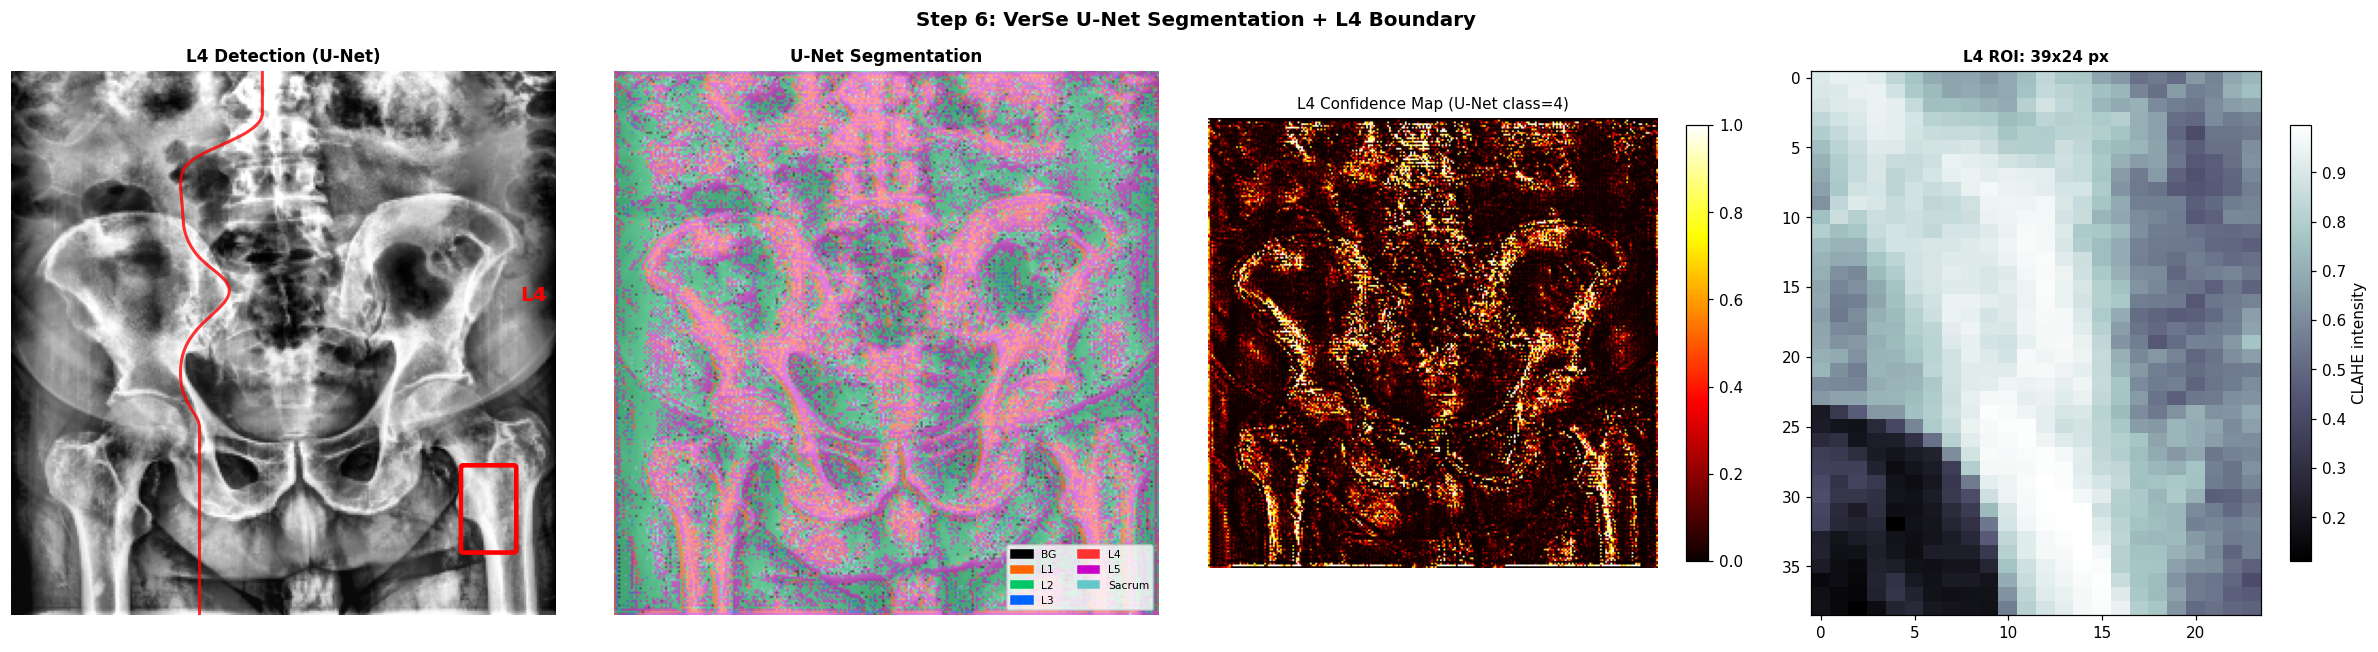

In [69]:
def unet_segment(model, clahe, device=DEVICE):
    """U-Net 추론 -> 척추체 세그멘테이션 마스크"""
    model.eval()
    t = torch.FloatTensor(clahe).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(t, deep_sup=False)   # (1,7,H,W)
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()   # (7,H,W)
    pred  = np.argmax(probs, axis=0).astype(np.uint8)       # (H,W)
    return pred, probs


def extract_l4_from_mask(pred_mask, probs, midline_x, l4_row_hint,
                          l4_x_hint, h, w):
    """
    U-Net 마스크에서 L4 ROI 정밀 추출

    Steps:
    1. class=4 (L4) 영역 추출
    2. midline_x[l4_row_hint] 근처에서 가장 큰 connected component 선택
    3. bounding box -> ROI 결정
    4. 마스크 없으면 heuristic fallback
    """
    L4_CLASS = 4
    l4_mask  = (pred_mask == L4_CLASS).astype(np.uint8)

    if l4_mask.sum() < 50:
        # U-Net이 L4를 못찾은 경우 -> heuristic 그대로 사용
        return None, None, None, False

    # Connected components
    labeled, n = nd_label(l4_mask)
    if n == 0:
        return None, None, None, False

    # midline 근처의 component 선택
    comp_scores = []
    for ci in range(1, n+1):
        comp = (labeled == ci)
        cx_comp = np.where(comp.any(axis=0))[0]
        cy_comp = np.where(comp.any(axis=1))[0]
        if len(cx_comp)==0 or len(cy_comp)==0: continue
        dist = abs(float(cx_comp.mean()) - l4_x_hint) +                abs(float(cy_comp.mean()) - l4_row_hint) * 0.5
        comp_scores.append((comp.sum(), -dist, ci))

    comp_scores.sort(reverse=True)
    best_ci = comp_scores[0][2]
    best_comp = (labeled == best_ci)

    # Bounding box with padding
    rows_with = np.where(best_comp.any(axis=1))[0]
    cols_with = np.where(best_comp.any(axis=0))[0]
    if len(rows_with)==0 or len(cols_with)==0:
        return None, None, None, False

    pad_y, pad_x = 4, 6
    y1 = max(0, rows_with.min()-pad_y);  y2 = min(h, rows_with.max()+pad_y+1)
    x1 = max(0, cols_with.min()-pad_x);  x2 = min(w, cols_with.max()+pad_x+1)

    # L4 confidence map
    l4_conf = probs[L4_CLASS]

    return best_comp, (y1,y2,x1,x2), l4_conf, True


# ── U-Net 추론 실행 ──
pred_mask, probs_map = unet_segment(unet, clahe)

l4_comp, unet_bbox, l4_conf, unet_ok = extract_l4_from_mask(
    pred_mask, probs_map, midline_x, l4_row, l4_sx, h, w)

if unet_ok and unet_bbox:
    uy1,uy2,ux1,ux2 = unet_bbox
    print(f"U-Net L4 boundary: y=[{uy1}:{uy2}], x=[{ux1}:{ux2}]")
    # U-Net bbox 사용 (heuristic보다 우선)
    final_y1,final_y2,final_x1,final_x2 = uy1,uy2,ux1,ux2
    detection_method = 'U-Net'
else:
    print("U-Net L4 not found -> heuristic bbox 사용")
    final_y1,final_y2,final_x1,final_x2 = t_l4,b_l4,l4_x1,l4_x2
    detection_method = 'Heuristic'

print(f"Detection method: {detection_method}")
print(f"Final L4 ROI: y=[{final_y1}:{final_y2}], x=[{final_x1}:{final_x2}]")

# 시각화
fig, axes = plt.subplots(1,4,figsize=(22,6))
CLASS_COLORS = {0:(0,0,0),1:(255,100,0),2:(0,200,100),3:(0,100,255),
                4:(255,50,50),5:(200,0,200),6:(100,200,200)}
CLASS_NAMES  = {0:'BG',1:'L1',2:'L2',3:'L3',4:'L4',5:'L5',6:'Sacrum'}

# 전체 이미지
ax = axes[0]
ax.imshow(clahe,cmap='gray')
ax.plot(midline_x, np.arange(h), 'r-', lw=2, alpha=0.8)
rect=mpatches.FancyBboxPatch((final_x1,final_y1),final_x2-final_x1,final_y2-final_y1,
     boxstyle='round,pad=1',lw=3,edgecolor='red',facecolor='none')
ax.add_patch(rect)
ax.text(final_x2+3,l4_row,'L4',color='red',fontsize=13,fontweight='bold',va='center')
ax.set_title(f'L4 Detection ({detection_method})',fontsize=11,fontweight='bold'); ax.axis('off')

# U-Net segmentation
ax = axes[1]
seg_rgb = np.zeros((*pred_mask.shape,3), dtype=np.uint8)
for cls, col in CLASS_COLORS.items():
    seg_rgb[pred_mask==cls] = col
ax.imshow(clahe,cmap='gray',alpha=0.5)
ax.imshow(seg_rgb, alpha=0.5)
ax.set_title('U-Net Segmentation',fontsize=11,fontweight='bold'); ax.axis('off')
patches=[mpatches.Patch(color=[c/255 for c in CLASS_COLORS[i]],label=CLASS_NAMES[i])
         for i in range(7)]
ax.legend(handles=patches,fontsize=7,loc='lower right',ncol=2)

# L4 confidence map
ax = axes[2]
im=ax.imshow(probs_map[4],cmap='hot',vmin=0,vmax=1)
plt.colorbar(im,ax=ax,shrink=0.8)
ax.set_title('L4 Confidence Map (U-Net class=4)',fontsize=10); ax.axis('off')

# L4 ROI
ax = axes[3]
l4_roi = clahe[final_y1:final_y2, final_x1:final_x2]
im2=ax.imshow(l4_roi,cmap='bone',aspect='auto')
plt.colorbar(im2,ax=ax,shrink=0.8,label='CLAHE intensity')
ax.set_title(f'L4 ROI: {l4_roi.shape[0]}x{l4_roi.shape[1]} px',fontsize=10,fontweight='bold')

plt.suptitle('Step 6: VerSe U-Net Segmentation + L4 Boundary',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/03_unet_l4.png',dpi=130,bbox_inches='tight')
plt.show()


## Step 7: Phantom-free Calibration

### 팬텀 없이 BMD를 보정하는 3단계 방법

팬텀(Hydroxyapatite phantom)은 고가 장비라 일반 임상 촬영에 없습니다.  
대신 **같은 이미지 안의 기준 조직**을 활용해 자동 보정합니다.

```
방법 1: Paraspinal Muscle Normalization
────────────────────────────────────────
  척추 옆 근육(paraspinal muscle) = 단기간 밀도 불변
  bone_norm = bone_intensity / muscle_intensity
  → 노출량(kVp, mAs) 변화에 강건

방법 2: Soft-tissue vs Bone Contrast Ratio
──────────────────────────────────────────
  CR = (bone_mean - muscle_mean) / muscle_std
  → 골밀도 높을수록 CR 증가

방법 3: Longitudinal Tracking (시계열 ΔT-score)
───────────────────────────────────────────────
  같은 환자 반복 촬영 → 변화율(ΔT/month) 계산
  절대값보다 변화율이 임상적으로 더 유용
```


In [70]:
def phantom_free_calibration(clahe, midline_x, iliac_row, cfg=CFG):
    """
    Phantom-free Soft-tissue 기반 자동 보정

    Returns
    -------
    calib : dict
        muscle_mean      : paraspinal 근육 평균 강도
        bone_to_muscle   : 뼈/근육 강도 비율 (정규화 계수)
        calibrated_norm  : bone intensity를 근육 기준으로 정규화한 값
    """
    h, w   = clahe.shape
    sw     = cfg['muscle_offset'][0]
    ew     = cfg['muscle_offset'][1]
    rm_above = cfg['muscle_rows_above']

    # Paraspinal muscle ROI: L3-L5 레벨 척추 양쪽
    r0m = max(0, iliac_row - rm_above)
    r1m = min(h, iliac_row + 10)

    muscle_vals = []
    for side in [1, -1]:           # 오른쪽, 왼쪽
        for r in range(r0m, r1m):
            mx  = int(np.clip(midline_x[r], ew, w-ew-1))
            xs  = mx + side*sw
            xe  = mx + side*ew
            x1m = int(min(xs,xe)); x2m = int(max(xs,xe))
            x1m = max(0,x1m); x2m = min(w,x2m)
            if x2m > x1m:
                muscle_vals.extend(clahe[r, x1m:x2m].tolist())

    muscle_mean  = float(np.median(muscle_vals)) if muscle_vals else 0.50
    muscle_std   = float(np.std(muscle_vals))    if muscle_vals else 0.05

    # 에어 ROI (이미지 외곽 = X-ray 직접 노출)
    air_samples  = np.concatenate([
        clahe[:15, :15].ravel(),
        clahe[:15, -15:].ravel()])
    air_mean  = float(np.percentile(air_samples, 5))

    return {
        'muscle_mean'     : muscle_mean,
        'muscle_std'      : muscle_std,
        'air_mean'        : air_mean,
        'contrast_range'  : max(air_mean - muscle_mean, 0.01),
        'n_muscle_pixels' : len(muscle_vals),
    }


def calibrated_bmd(l4_roi, calib, cfg=CFG):
    """
    Paraspinal muscle 기준 calibrated BMD 계산

    T_calibrated = (bone_normalized - ref_young) / ref_young_std
    bone_normalized = bone_mean / muscle_mean × 10000 (phantom 단위 스케일)
    """
    if l4_roi is None or l4_roi.size == 0:
        return None

    flat   = l4_roi.ravel()
    lo, hi = np.percentile(flat, [10, 90])
    core   = flat[(flat>=lo) & (flat<=hi)]
    bone_mean = float(np.mean(core)) if len(core)>0 else float(flat.mean())

    # Muscle normalization
    mu     = calib['muscle_mean']
    bone_norm = bone_mean / mu if mu > 1e-6 else bone_mean

    # phantom-scale (CLAHE 0~1 -> 가상 HU 스케일로 매핑)
    phantom_scale = bone_norm * cfg['ref_young_mean']

    # T-score
    ts_calibrated = (phantom_scale - cfg['ref_young_mean']) / cfg['ref_young_std']
    zs_calibrated = (phantom_scale - cfg['ref_age_mean'])   / cfg['ref_age_std']

    # Bone-to-muscle contrast ratio (추가 지표)
    cr = (bone_mean - mu) / max(calib['muscle_std'], 0.01)

    # Proxy (raw, calibration 없음)
    ts_proxy = (bone_mean*cfg['ref_young_mean'] - cfg['ref_young_mean']) / cfg['ref_young_std']

    if   ts_calibrated >= -1.0: who,risk,col="Normal",        "Low",     "#27ae60"
    elif ts_calibrated >= -2.5: who,risk,col="Osteopenia",    "Moderate","#e67e22"
    else:                       who,risk,col="Osteoporosis",   "High",    "#e74c3c"

    return {
        'bone_mean'       : bone_mean,
        'muscle_mean'     : mu,
        'bone_norm'       : bone_norm,
        'phantom_scale'   : phantom_scale,
        'ts_calibrated'   : ts_calibrated,
        'zs_calibrated'   : zs_calibrated,
        'ts_proxy'        : ts_proxy,
        'contrast_ratio'  : cr,
        'who'             : who,
        'risk'            : risk,
        'color'           : col,
    }


# ── 실행 ──
calib_info = phantom_free_calibration(clahe, midline_x, iliac_row)
l4_roi     = clahe[final_y1:final_y2, final_x1:final_x2]
bmd_result = calibrated_bmd(l4_roi, calib_info)

print("=" * 52)
print("  Phantom-free Calibration 결과")
print("=" * 52)
print(f"  Muscle mean (기준)    : {calib_info['muscle_mean']:.4f}")
print(f"  Muscle std            : {calib_info['muscle_std']:.4f}")
print(f"  N muscle pixels       : {calib_info['n_muscle_pixels']}")
print(f"  Air mean              : {calib_info['air_mean']:.4f}")
print("-" * 52)
print(f"  Bone mean (L4)        : {bmd_result['bone_mean']:.4f}")
print(f"  Bone / Muscle ratio   : {bmd_result['bone_norm']:.4f}")
print(f"  Contrast Ratio        : {bmd_result['contrast_ratio']:.2f}")
print("-" * 52)
print(f"  T-Score (calibrated)  : {bmd_result['ts_calibrated']:+.2f}")
print(f"  T-Score (proxy/raw)   : {bmd_result['ts_proxy']:+.2f}")
print(f"  Z-Score               : {bmd_result['zs_calibrated']:+.2f}")
print("-" * 52)
print(f"  WHO 분류              : {bmd_result['who']}")
print(f"  골절 위험             : {bmd_result['risk']}")
print("=" * 52)


  Phantom-free Calibration 결과
  Muscle mean (기준)    : 0.4323
  Muscle std            : 0.2454
  N muscle pixels       : 2400
  Air mean              : 0.0278
----------------------------------------------------
  Bone mean (L4)        : 0.7173
  Bone / Muscle ratio   : 1.6592
  Contrast Ratio        : 1.16
----------------------------------------------------
  T-Score (calibrated)  : +8.57
  T-Score (proxy/raw)   : -3.67
  Z-Score               : +6.93
----------------------------------------------------
  WHO 분류              : Normal
  골절 위험             : Low


## Step 8: Longitudinal Tracking (시계열 BMD 변화)

골반 수술 환자 추적 관찰에서 가장 중요한 것은  
**절대 BMD 값**이 아닌 **시간에 따른 변화율**입니다.

```
- 수술 전: T-score = -1.8
- 수술 후 6개월: T-score = -2.1  → ΔT = -0.3/6mo
- 수술 후 12개월: T-score = -2.3 → ΔT = -0.2/6mo
→ 골밀도 감소 속도가 둔화됨 → 치료 효과 확인
```


Patient 75 측정 기록: 1회
Trend: insufficient data


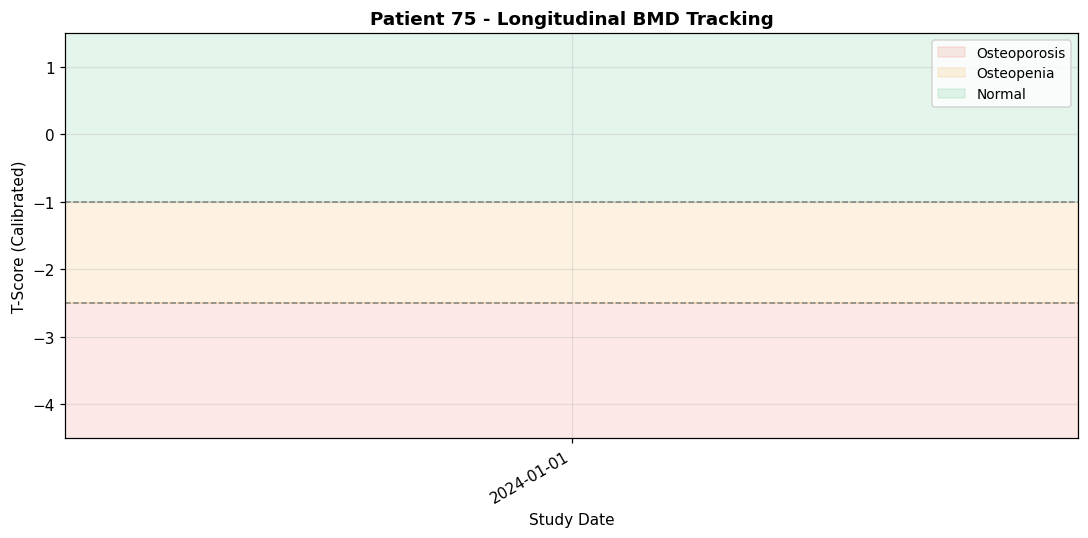

Trend: insufficient data | ΔT/month: None


In [71]:
class LongitudinalBMDTracker:
    """
    환자별 시계열 BMD 추적 관리자

    - JSON 파일에 환자별 측정값 누적
    - 선형 회귀로 월별 변화율(ΔT/month) 계산
    - 골밀도 변화 추세 분류
    """
    def __init__(self, db_path=LONGIT_DB):
        self.db_path = db_path
        self.db      = self._load()

    def _load(self):
        if os.path.exists(self.db_path):
            with open(self.db_path,'r') as f:
                return json.load(f)
        return {}

    def _save(self):
        with open(self.db_path,'w') as f:
            json.dump(self.db, f, indent=2, ensure_ascii=False)

    def add_measurement(self, patient_id, study_date, ts_calibrated,
                        ts_proxy, bmd_result, meta=None):
        """측정값 추가"""
        if patient_id not in self.db:
            self.db[patient_id] = []

        # 날짜 파싱 (YYYYMMDD)
        try:
            dt = datetime.datetime.strptime(str(study_date),'%Y%m%d')
            date_str = dt.strftime('%Y-%m-%d')
        except:
            date_str = str(study_date) or datetime.datetime.now().strftime('%Y-%m-%d')

        record = {
            'date'          : date_str,
            'ts_calibrated' : float(ts_calibrated),
            'ts_proxy'      : float(ts_proxy),
            'who'           : bmd_result.get('who',''),
            'risk'          : bmd_result.get('risk',''),
            'bone_muscle_r' : float(bmd_result.get('bone_norm',0)),
            'contrast_ratio': float(bmd_result.get('contrast_ratio',0)),
            'filename'      : meta.get('filename','') if meta else '',
        }
        # 중복 날짜 방지
        self.db[patient_id] = [r for r in self.db[patient_id] if r['date']!=date_str]
        self.db[patient_id].append(record)
        self.db[patient_id].sort(key=lambda x: x['date'])
        self._save()
        return record

    def get_trend(self, patient_id):
        """
        환자의 BMD 변화 추세 분석

        Returns
        -------
        dict:
            records      : 전체 측정 기록
            delta_per_mo : 월별 T-score 변화율 (선형 회귀)
            trend        : 'improving' / 'stable' / 'declining'
            r2           : 선형 회귀 R²
        """
        records = self.db.get(patient_id, [])
        if len(records) < 2:
            return {'records':records,'delta_per_mo':None,'trend':'insufficient data','r2':None}

        dates  = [datetime.datetime.strptime(r['date'],'%Y-%m-%d') for r in records]
        ref    = dates[0]
        months = [(d - ref).days / 30.44 for d in dates]
        scores = [r['ts_calibrated'] for r in records]

        X = np.array(months).reshape(-1,1)
        y = np.array(scores)
        reg = LinearRegression().fit(X,y)
        delta = float(reg.coef_[0])
        r2    = float(reg.score(X,y))

        if   delta >  0.05: trend = 'improving'
        elif delta < -0.05: trend = 'declining'
        else:               trend = 'stable'

        return {'records':records,'delta_per_mo':delta,
                'trend':trend,'r2':r2,'months':months,'scores':scores}

    def plot_trend(self, patient_id, save_path=None):
        """환자 시계열 BMD 그래프"""
        info = self.get_trend(patient_id)
        if len(info['records']) < 1:
            print(f"No data for {patient_id}")
            return

        fig, ax = plt.subplots(figsize=(10,5))
        dates  = [r['date'] for r in info['records']]
        scores = [r['ts_calibrated'] for r in info['records']]
        who    = [r['who'] for r in info['records']]

        color_map = {'Normal':'#27ae60','Osteopenia':'#e67e22','Osteoporosis':'#e74c3c'}
        for i,(d,s,w) in enumerate(zip(dates,scores,who)):
            ax.scatter(d, s, s=120, color=color_map.get(w,'gray'), zorder=5)
        ax.plot(dates, scores, 'k--', lw=1.5, alpha=0.6)

        # WHO 영역
        ax.axhspan(-5, -2.5, alpha=0.12, color='#e74c3c', label='Osteoporosis')
        ax.axhspan(-2.5,-1.0, alpha=0.12, color='#f39c12', label='Osteopenia')
        ax.axhspan(-1.0, 2.0, alpha=0.12, color='#27ae60', label='Normal')
        ax.axhline(-2.5, color='gray', lw=1, linestyle='--')
        ax.axhline(-1.0, color='gray', lw=1, linestyle='--')

        # 추세선
        if info['delta_per_mo'] is not None and len(scores)>=2:
            mo = info['months']
            xs = [dates[0]] * len(mo)   # x축 string 대신 months 사용
            trend_y = [scores[0] + info['delta_per_mo']*m for m in mo]
            ax.plot(dates, trend_y, 'b-', lw=2,
                    label=f"Trend: {info['delta_per_mo']:+.3f}/mo (R²={info['r2']:.2f})")

        ax.set_ylim(-4.5, 1.5); ax.set_xlabel('Study Date'); ax.set_ylabel('T-Score (Calibrated)')
        ax.set_title(f"Patient {patient_id} - Longitudinal BMD Tracking",
                     fontsize=12, fontweight='bold')
        ax.legend(fontsize=9); ax.grid(alpha=0.3)
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=120, bbox_inches='tight')
        plt.show()
        print(f"Trend: {info['trend']} | ΔT/month: {info['delta_per_mo']}")


# ── 시계열 트래커 초기화 & 현재 측정값 기록 ──
tracker = LongitudinalBMDTracker(LONGIT_DB)
tracker.add_measurement(
    patient_id   = meta['patient_id'],
    study_date   = meta['study_date'] or '20240101',
    ts_calibrated= bmd_result['ts_calibrated'],
    ts_proxy     = bmd_result['ts_proxy'],
    bmd_result   = bmd_result,
    meta         = meta
)
trend_info = tracker.get_trend(meta['patient_id'])
print(f"Patient {meta['patient_id']} 측정 기록: {len(trend_info['records'])}회")
print(f"Trend: {trend_info['trend']}")
tracker.plot_trend(meta['patient_id'],
                   save_path=f"{RESULT_DIR}/04_longitudinal.png")


## Step 9: 최종 BMD 대시보드

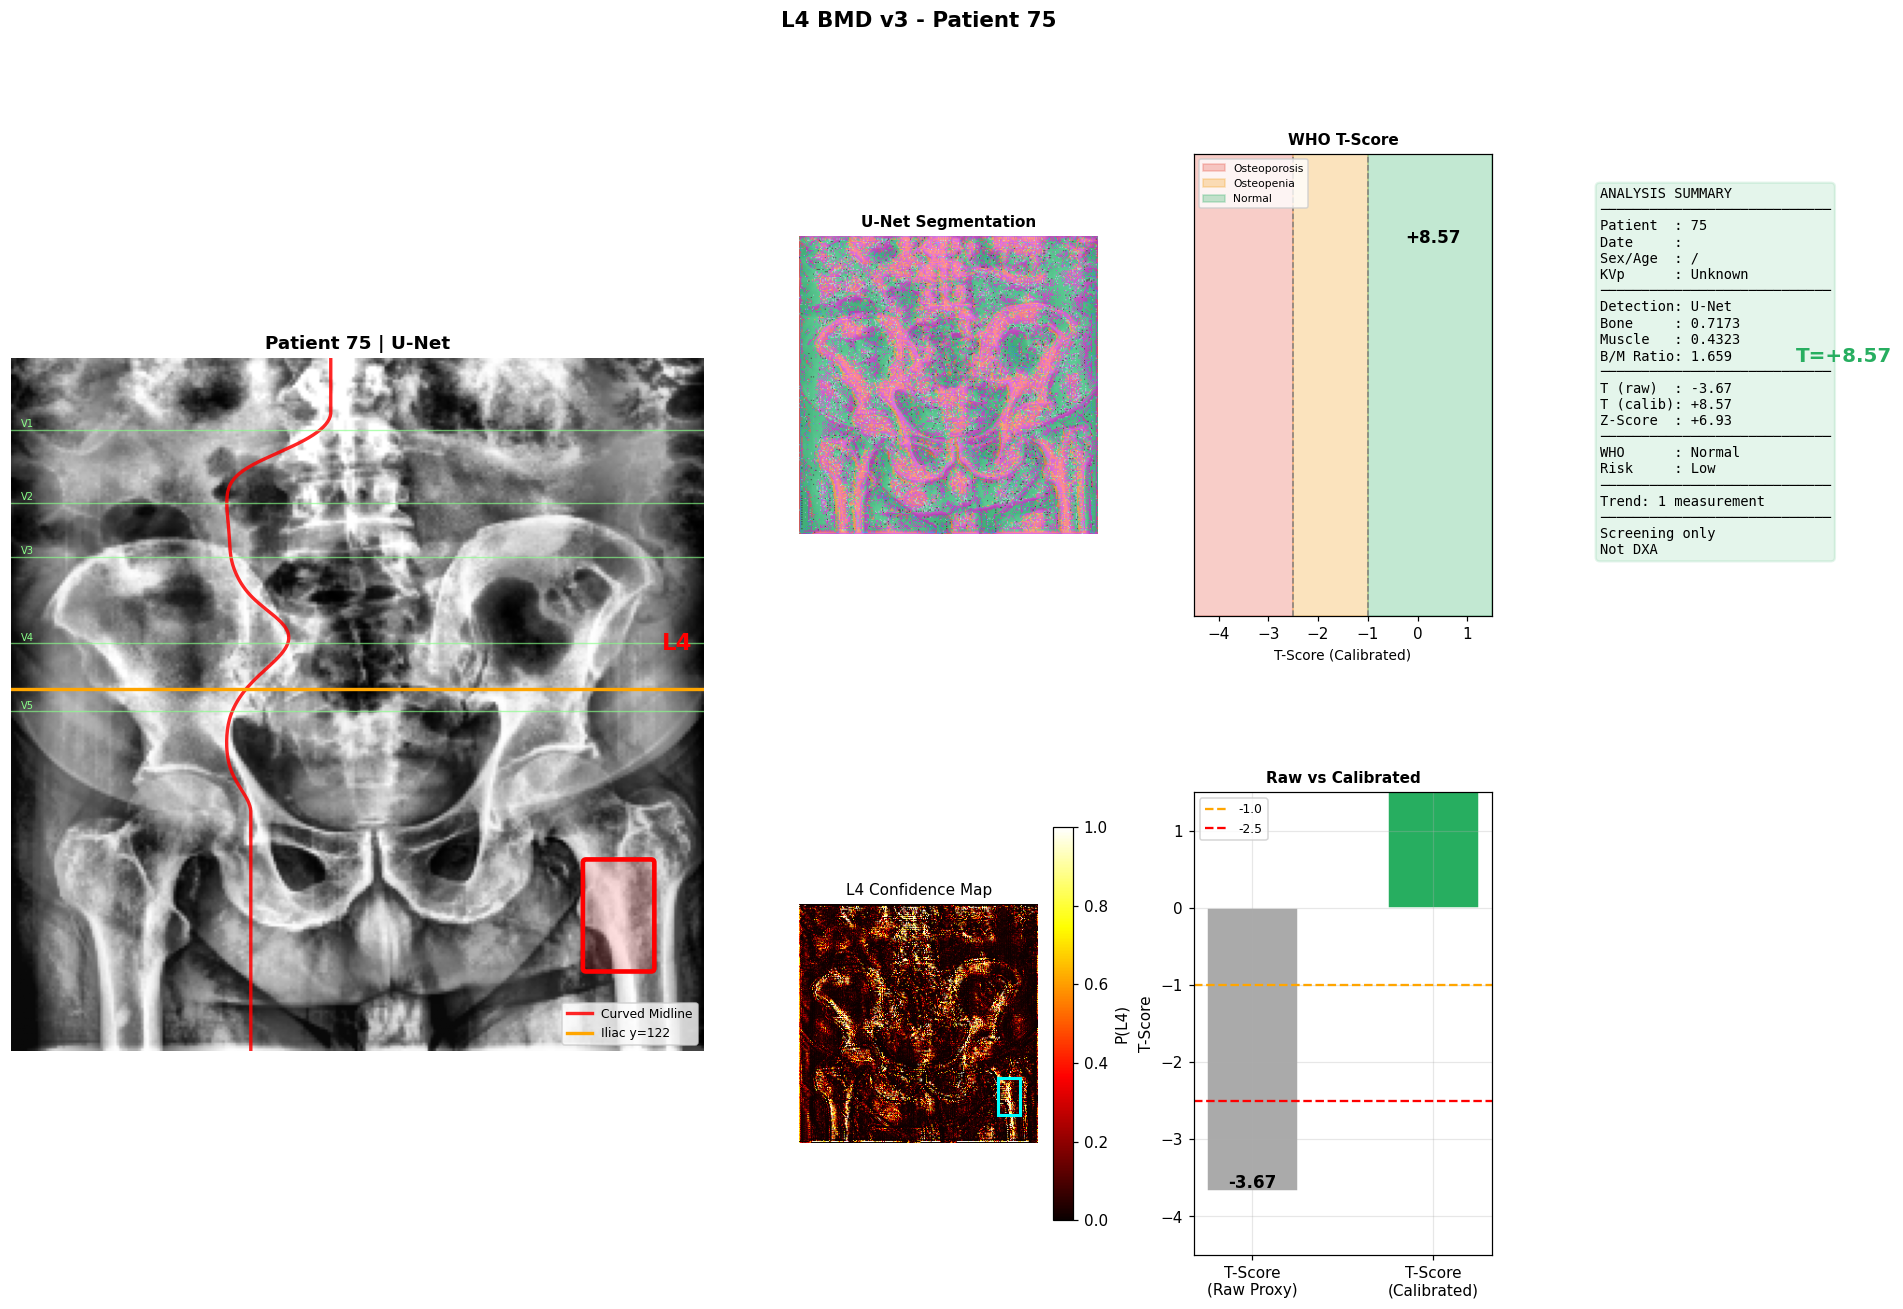

In [72]:
def plot_bmd_dashboard_v3(clahe, midline_x, iliac_row, peaks_abs,
                           final_y1, final_y2, final_x1, final_x2,
                           l4_row, pred_mask, probs_map,
                           bmd_result, calib_info, trend_info,
                           meta, detection_method='Heuristic',
                           save_path=None):
    h, w = clahe.shape
    fig  = plt.figure(figsize=(22, 13))
    gs   = GridSpec(2, 5, figure=fig, hspace=0.38, wspace=0.32)

    # ── [전체 이미지 + Curved Midline + L4] ──
    ax = fig.add_subplot(gs[:, 0:2])
    ax.imshow(clahe, cmap='gray')
    ax.plot(midline_x, np.arange(h), 'r-', lw=2.2, alpha=0.85, label='Curved Midline')
    ax.axhline(iliac_row, color='#FFA500', lw=2.2, label=f'Iliac y={iliac_row}')
    for i, p in enumerate(peaks_abs):
        ax.axhline(p, color='#88FF88', lw=0.9, alpha=0.65)
        ax.text(3, p-1, f'V{i+1}', fontsize=6.5, color='#88FF88')
    rect  = mpatches.FancyBboxPatch((final_x1,final_y1),final_x2-final_x1,final_y2-final_y1,
                boxstyle='round,pad=1.2',lw=3,edgecolor='red',facecolor='red',alpha=0.12)
    rect2 = mpatches.FancyBboxPatch((final_x1,final_y1),final_x2-final_x1,final_y2-final_y1,
                boxstyle='round,pad=1.2',lw=3,edgecolor='red',facecolor='none')
    ax.add_patch(rect); ax.add_patch(rect2)
    ax.text(final_x2+4, l4_row, 'L4', color='red', fontsize=15, fontweight='bold', va='center')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_title(f"Patient {meta['patient_id']} | {detection_method}",
                 fontsize=12, fontweight='bold')
    ax.axis('off')

    # ── [U-Net 세그멘테이션] ──
    ax = fig.add_subplot(gs[0, 2])
    CLASS_COLORS = {0:(0,0,0),1:(255,130,0),2:(0,200,100),3:(0,130,255),
                    4:(255,50,50),5:(200,0,200),6:(130,200,200)}
    seg_rgb = np.zeros((*pred_mask.shape,3),dtype=np.uint8)
    for cls,col in CLASS_COLORS.items(): seg_rgb[pred_mask==cls]=col
    ax.imshow(clahe, cmap='gray', alpha=0.45)
    ax.imshow(seg_rgb, alpha=0.55)
    ax.set_title('U-Net Segmentation', fontsize=10, fontweight='bold'); ax.axis('off')

    # ── [L4 Confidence Map] ──
    ax = fig.add_subplot(gs[1, 2])
    im = ax.imshow(probs_map[4], cmap='hot', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, shrink=0.85, label='P(L4)')
    rect3 = mpatches.Rectangle((final_x1,final_y1),final_x2-final_x1,final_y2-final_y1,
                fill=False, edgecolor='cyan', lw=2)
    ax.add_patch(rect3)
    ax.set_title('L4 Confidence Map', fontsize=10); ax.axis('off')

    # ── [T-Score Gauge] ──
    ax = fig.add_subplot(gs[0, 3])
    t = bmd_result['ts_calibrated']
    ax.set_xlim(-4.5,1.5); ax.set_ylim(0,1)
    ax.axvspan(-4.5,-2.5,color='#e74c3c',alpha=0.28,label='Osteoporosis')
    ax.axvspan(-2.5,-1.0,color='#f39c12',alpha=0.28,label='Osteopenia')
    ax.axvspan(-1.0, 1.5,color='#27ae60',alpha=0.28,label='Normal')
    ax.axvline(t, color=bmd_result['color'], lw=5)
    ax.axvline(-2.5,color='gray',lw=1,linestyle='--'); ax.axvline(-1.0,color='gray',lw=1,linestyle='--')
    ax.text(t,0.55,f'T={t:+.2f}',color=bmd_result['color'],
            fontsize=13,fontweight='bold',ha='center')
    ax.set_xlabel('T-Score (Calibrated)',fontsize=9); ax.set_yticks([]); ax.legend(fontsize=7,loc='upper left')
    ax.set_title('WHO T-Score',fontsize=10,fontweight='bold')

    # ── [Calibration 비교] ──
    ax = fig.add_subplot(gs[1, 3])
    labels_cmp = ['T-Score\n(Raw Proxy)', 'T-Score\n(Calibrated)']
    vals_cmp   = [bmd_result['ts_proxy'], bmd_result['ts_calibrated']]
    colors_cmp = ['#aaaaaa', bmd_result['color']]
    bars = ax.bar(labels_cmp, vals_cmp, color=colors_cmp, edgecolor='white', width=0.5)
    ax.axhline(-1.0,color='orange',lw=1.5,linestyle='--',label='-1.0')
    ax.axhline(-2.5,color='red',   lw=1.5,linestyle='--',label='-2.5')
    for bar,v in zip(bars,vals_cmp):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:+.2f}',
                ha='center', fontsize=11, fontweight='bold')
    ax.set_ylim(-4.5,1.5); ax.set_ylabel('T-Score'); ax.legend(fontsize=8)
    ax.set_title('Raw vs Calibrated',fontsize=10,fontweight='bold'); ax.grid(alpha=0.3)

    # ── [요약] ──
    ax = fig.add_subplot(gs[:, 4]); ax.axis('off')
    m = meta
    trend_str = (f"ΔT/mo: {trend_info['delta_per_mo']:+.3f}\n"
                 f"Trend: {trend_info['trend']}\n"
                 f"N obs: {len(trend_info['records'])}")                  if trend_info['delta_per_mo'] is not None else "Trend: 1 measurement"
    summary = (f"ANALYSIS SUMMARY\n"
               f"{'─'*28}\n"
               f"Patient  : {m['patient_id']}\n"
               f"Date     : {m['study_date']}\n"
               f"Sex/Age  : {m['patient_sex']}/{m['patient_age']}\n"
               f"KVp      : {m.get('kvp','?')}\n"
               f"{'─'*28}\n"
               f"Detection: {detection_method}\n"
               f"Bone     : {bmd_result['bone_mean']:.4f}\n"
               f"Muscle   : {calib_info['muscle_mean']:.4f}\n"
               f"B/M Ratio: {bmd_result['bone_norm']:.3f}\n"
               f"{'─'*28}\n"
               f"T (raw)  : {bmd_result['ts_proxy']:+.2f}\n"
               f"T (calib): {bmd_result['ts_calibrated']:+.2f}\n"
               f"Z-Score  : {bmd_result['zs_calibrated']:+.2f}\n"
               f"{'─'*28}\n"
               f"WHO      : {bmd_result['who']}\n"
               f"Risk     : {bmd_result['risk']}\n"
               f"{'─'*28}\n"
               f"{trend_str}\n"
               f"{'─'*28}\n"
               f"Screening only\nNot DXA")
    ax.text(0.04, 0.97, summary, transform=ax.transAxes, fontsize=9, va='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round',facecolor=bmd_result['color'],
                      alpha=0.12,edgecolor=bmd_result['color'],lw=1.5))

    plt.suptitle(f"L4 BMD v3 - Patient {m['patient_id']}",
                 fontsize=14, fontweight='bold')
    if save_path: plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()


plot_bmd_dashboard_v3(
    clahe, midline_x, iliac_row, peaks_abs,
    final_y1, final_y2, final_x1, final_x2,
    l4_row, pred_mask, probs_map,
    bmd_result, calib_info, trend_info, meta,
    detection_method=detection_method,
    save_path=f'{RESULT_DIR}/05_bmd_dashboard_v3.png'
)


## Step 10: 완전 파이프라인 함수 & U-Net Fine-tuning

In [73]:
def full_pipeline_v3(path, unet_model=None, cfg=CFG):
    """DICOM -> Calibrated BMD 완전 파이프라인 (v3)"""
    r = {'status':'OK','filename':os.path.basename(path)}
    try:
        arr_d, meta, _ = load_dicom(path)
        norm_d, clahe_d, _ = preprocess_xray(arr_d, cfg['img_size'])
        h_d, w_d = clahe_d.shape

        ml_x, _          = detect_curved_midline(clahe_d, cfg)
        p_abs,tr_abs,rp,rs= detect_vertebrae_curved(clahe_d, ml_x, cfg)
        iliac_r           = detect_iliac_crest(clahe_d, cfg)
        l4r,l4sx,tl4,bl4,l4x1,l4x2 = localize_l4(p_abs,tr_abs,iliac_r,h_d,ml_x,w_d,cfg)

        # U-Net 세그멘테이션
        model = unet_model if unet_model else unet
        pm, pb = unet_segment(model, clahe_d)
        comp, u_bbox, conf, u_ok = extract_l4_from_mask(pm, pb, ml_x, l4r, l4sx, h_d, w_d)
        if u_ok and u_bbox:
            fy1,fy2,fx1,fx2 = u_bbox; method='U-Net'
        else:
            fy1,fy2,fx1,fx2 = tl4,bl4,l4x1,l4x2; method='Heuristic'

        roi    = clahe_d[fy1:fy2, fx1:fx2]
        calib  = phantom_free_calibration(clahe_d, ml_x, iliac_r, cfg)
        bmd_r  = calibrated_bmd(roi, calib, cfg)

        r.update({'meta':meta,'clahe':clahe_d,'midline_x':ml_x,
                  'iliac_row':iliac_r,'peaks_abs':p_abs,'troughs_abs':tr_abs,
                  'rp_s':rp,'r_start':rs,
                  'l4_row':l4r,'l4_spine_x':l4sx,
                  'final_y1':fy1,'final_y2':fy2,'final_x1':fx1,'final_x2':fx2,
                  'pred_mask':pm,'probs_map':pb,'detection_method':method,
                  'l4_roi':roi,'calib':calib,'bmd':bmd_r})
    except Exception as e:
        import traceback
        r['status'] = f'ERROR: {e}'; r['traceback'] = traceback.format_exc()
    return r


In [74]:
# ══════════════════════════════════════════════════════════
# U-Net Fine-tuning (척추 마스크 레이블 있을 때)
# ══════════════════════════════════════════════════════════

class SpineSegDataset(Dataset):
    """
    척추 세그멘테이션 Dataset

    mask_dir 없으면: pseudo-label 자동 생성 (heuristic 기반)
    mask_dir 있으면: 실제 레이블 마스크 사용 (0-6 클래스)
    """
    def __init__(self, dcm_paths, mask_dir=None, augment=False, cfg=CFG):
        self.paths    = dcm_paths
        self.mask_dir = mask_dir
        self.augment  = augment
        self.cfg      = cfg

    def __len__(self): return len(self.paths)

    def _pseudo_mask(self, clahe, midline_x, peaks_abs, troughs_abs, l4_row):
        """Heuristic pseudo-label (레이블 없을 때 자동 생성)"""
        h, w = clahe.shape
        mask = np.zeros((h,w), dtype=np.uint8)
        sw   = self.cfg['strip_width']
        # 각 척추체: peaks 순서로 L-class 할당 (상단부터 L1=1...)
        label_map = {}
        vert_list = sorted(peaks_abs)
        for i, p in enumerate(vert_list):
            if i >= 6: break
            label_map[p] = i + 1  # 1=L1, ..., 5=L5, 6=Sacrum

        for p, cls in label_map.items():
            t_a = troughs_abs[troughs_abs < p]
            t_b = troughs_abs[troughs_abs > p]
            top = int(t_a[-1]) if len(t_a)>0 else max(0,p-12)
            bot = int(t_b[ 0]) if len(t_b)>0 else min(h,p+12)
            for r in range(top, bot):
                mx  = int(np.clip(midline_x[r], sw, w-sw-1))
                x1m = max(0, mx-sw); x2m = min(w, mx+sw)
                mask[r, x1m:x2m] = cls
        return mask

    def __getitem__(self, idx):
        path  = self.paths[idx]
        try:
            arr_d,meta,_ = load_dicom(path)
            _,clahe_d,_  = preprocess_xray(arr_d, self.cfg['img_size'])
            ml_x,_       = detect_curved_midline(clahe_d, self.cfg)
            p_abs,tr_abs,_,_ = detect_vertebrae_curved(clahe_d, ml_x, self.cfg)
            il_r         = detect_iliac_crest(clahe_d, self.cfg)
            l4r,_,_,_,_,_ = localize_l4(p_abs,tr_abs,il_r,
                                          clahe_d.shape[0],ml_x,clahe_d.shape[1],self.cfg)
            # 마스크
            fname  = os.path.basename(path).replace('.dcm','.png')
            mp     = os.path.join(self.mask_dir, fname) if self.mask_dir else None
            if mp and os.path.exists(mp):
                mask = cv2.imread(mp, cv2.IMREAD_GRAYSCALE).astype(np.int64)
            else:
                mask = self._pseudo_mask(clahe_d, ml_x, p_abs, tr_abs, l4r)

            img_t  = torch.FloatTensor(clahe_d).unsqueeze(0)
            mask_t = torch.LongTensor(mask)
            return {'image':img_t, 'mask':mask_t, 'filename':os.path.basename(path)}
        except:
            sz = self.cfg['img_size']
            return {'image':torch.zeros(1,sz,sz),'mask':torch.zeros(sz,sz,dtype=torch.long),
                    'filename':os.path.basename(path)}


class DeepSupLoss(nn.Module):
    """Deep Supervision Loss: main + 0.4×(ds1+ds2)"""
    def __init__(self, weight=0.4, n_classes=7):
        super().__init__()
        self.w     = weight
        self.ce    = nn.CrossEntropyLoss()
        self.n     = n_classes

    def forward(self, outputs, target):
        if isinstance(outputs, tuple):
            main, ds1, ds2 = outputs
            # ds1,ds2는 다운샘플 -> target도 다운샘플
            t1 = F.interpolate(target.float().unsqueeze(1),
                               size=ds1.shape[-2:], mode='nearest').squeeze(1).long()
            t2 = F.interpolate(target.float().unsqueeze(1),
                               size=ds2.shape[-2:], mode='nearest').squeeze(1).long()
            return (self.ce(main,target) +
                    self.w*self.ce(ds1,t1) +
                    self.w*self.ce(ds2,t2))
        return self.ce(outputs, target)


def train_unet(model, dl_tr, dl_va, cfg=CFG, save_path=None):
    """U-Net 훈련 루프 (Deep Supervision + IoU 검증)"""
    opt     = optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    sch     = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg['num_epochs'], eta_min=1e-6)
    loss_fn = DeepSupLoss(weight=cfg['deep_sup_weight'])
    hist    = {'tr_loss':[],'va_loss':[],'va_l4iou':[]}
    best_iou, pat = 0.0, 0

    for ep in range(1, cfg['num_epochs']+1):
        model.train()
        tr_l = 0.0
        for b in tqdm(dl_tr, desc=f'Ep{ep:3d}', leave=False, ncols=70):
            imgs = b['image'].to(DEVICE)
            msks = b['mask'].to(DEVICE)
            opt.zero_grad()
            out = model(imgs, deep_sup=True)
            loss = loss_fn(out, msks); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            tr_l += loss.item()
        tr_l /= max(len(dl_tr),1); sch.step()

        model.eval(); va_l=0.0; l4iou=0.0
        with torch.no_grad():
            for b in dl_va:
                imgs,msks = b['image'].to(DEVICE), b['mask'].to(DEVICE)
                out  = model(imgs, deep_sup=False)
                va_l+= loss_fn(out, msks).item()
                pred = out.argmax(1)
                inter= ((pred==4) & (msks==4)).float().sum()
                union= ((pred==4) | (msks==4)).float().sum()
                l4iou += (inter/(union+1e-6)).item()
        va_l /= max(len(dl_va),1); l4iou /= max(len(dl_va),1)

        hist['tr_loss'].append(tr_l); hist['va_loss'].append(va_l); hist['va_l4iou'].append(l4iou)

        if l4iou > best_iou:
            best_iou=l4iou; pat=0
            if save_path: torch.save(model.state_dict(), save_path)
            print(f"Ep{ep:3d} | tr={tr_l:.4f} val={va_l:.4f} L4-IoU={l4iou:.3f} [saved]")
        else:
            pat+=1
            if ep%5==0: print(f"Ep{ep:3d} | tr={tr_l:.4f} val={va_l:.4f} L4-IoU={l4iou:.3f} pat={pat}")
            if pat>=cfg['early_stop']: print(f"Early stop @{ep}"); break

    return hist


def build_seg_dataloaders(root, mask_dir=None, cfg=CFG):
    def gdcm(d):
        return list(set(
            glob.glob(os.path.join(d,'*.dcm'))+
            glob.glob(os.path.join(d,'*.DCM'))+
            glob.glob(os.path.join(d,'**','*.dcm'),recursive=True)))
    tr=gdcm(os.path.join(root,'train'))
    va=gdcm(os.path.join(root,'val'))
    te=gdcm(os.path.join(root,'test'))
    if not tr:
        all_f=gdcm(root)
        if not all_f: return None,None,None
        np.random.seed(42); idx=np.random.permutation(len(all_f))
        ntr=int(len(idx)*cfg['train_ratio']); nva=int(len(idx)*cfg['val_ratio'])
        tr=[all_f[i] for i in idx[:ntr]]
        va=[all_f[i] for i in idx[ntr:ntr+nva]]
        te=[all_f[i] for i in idx[ntr+nva:]]
    print(f"Seg dataset: train={len(tr)}, val={len(va)}, test={len(te)}")
    mk=lambda p,aug: DataLoader(SpineSegDataset(p,mask_dir,aug,cfg),
                                 batch_size=cfg['batch_size'],shuffle=aug,num_workers=0)
    return mk(tr,True), mk(va,False), mk(te,False)


# ── 훈련 실행 ──
RUN_SEG = os.path.exists(DATASET_ROOT) and len(
    glob.glob(os.path.join(DATASET_ROOT,'**','*.dcm'),recursive=True))>0

MASK_DIR = "./dataset/masks"   # PNG 마스크 있으면 경로 지정 (없으면 pseudo-label)

print(f"Dataset: {RUN_SEG}")
if RUN_SEG:
    UNET_CKPT = f'{MODEL_DIR}/best_unet.pth'
    dl_tr,dl_va,dl_te = build_seg_dataloaders(
        DATASET_ROOT,
        mask_dir=MASK_DIR if os.path.exists(MASK_DIR) else None,
        cfg=CFG)
    if dl_tr:
        print(f"U-Net 훈련 시작 (Deep Supervision, {CFG['num_epochs']}epoch)")
        hist = train_unet(unet, dl_tr, dl_va, CFG, UNET_CKPT)
        fig,axes=plt.subplots(1,2,figsize=(12,4))
        ep=range(1,len(hist['tr_loss'])+1)
        axes[0].plot(ep,hist['tr_loss'],label='Train'); axes[0].plot(ep,hist['va_loss'],label='Val')
        axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
        axes[1].plot(ep,hist['va_l4iou'],color='tomato')
        axes[1].set_title('Val L4-IoU'); axes[1].grid(alpha=0.3)
        plt.tight_layout(); plt.savefig(f'{RESULT_DIR}/unet_training.png',dpi=120); plt.show()
else:
    print("Dataset 미준비 -> single-file inference mode")
    print("데이터셋 준비 후 DATASET_ROOT 경로 설정하고 재실행")


Dataset: False
Dataset 미준비 -> single-file inference mode
데이터셋 준비 후 DATASET_ROOT 경로 설정하고 재실행


## Step 11: 배치 처리 & CSV 리포트

In [75]:
def run_batch_v3(paths, unet_model=None, tracker=None, save_dir=None):
    if save_dir: os.makedirs(save_dir, exist_ok=True)
    rows = []
    for i,p in enumerate(tqdm(paths,desc='Batch v3',ncols=70)):
        r = full_pipeline_v3(p, unet_model)
        row = {'idx':i+1,'filename':os.path.basename(p),'status':r['status']}
        if r['status']=='OK':
            m=r['meta']; bmd=r['bmd']; cal=r['calib']
            if bmd:
                row.update({
                    'patient_id'   :m['patient_id'],
                    'study_date'   :m['study_date'],
                    'detection'    :r['detection_method'],
                    'l4_row'       :r['l4_row'],
                    'bone_mean'    :f"{bmd['bone_mean']:.4f}",
                    'muscle_mean'  :f"{cal['muscle_mean']:.4f}",
                    'bone_muscle_r':f"{bmd['bone_norm']:.4f}",
                    'ts_calibrated':f"{bmd['ts_calibrated']:+.3f}",
                    'ts_proxy'     :f"{bmd['ts_proxy']:+.3f}",
                    'z_score'      :f"{bmd['zs_calibrated']:+.3f}",
                    'who'          :bmd['who'],
                    'risk'         :bmd['risk'],
                })
                if tracker:
                    tracker.add_measurement(m['patient_id'],m['study_date'],
                                             bmd['ts_calibrated'],bmd['ts_proxy'],bmd,m)
        rows.append(row)

    df = pd.DataFrame(rows)
    csv_p = os.path.join(save_dir or '.','bmd_v3_report.csv')
    df.to_csv(csv_p, index=False)
    ok = df[df['status']=='OK']
    print(f"\nBatch done: {len(rows)} | OK: {len(ok)}")
    if len(ok)>0 and 'ts_calibrated' in ok.columns:
        ts=ok['ts_calibrated'].astype(float)
        print(f"T-Score(calibrated): mean={ts.mean():+.2f} min={ts.min():+.2f} max={ts.max():+.2f}")
        for cls, cnt in ok['who'].value_counts().items():
            print(f"  {cls:25s}: {cnt} ({cnt/len(ok)*100:.1f}%)")
    return df


files = list(set(
    glob.glob('./*.dcm') + glob.glob('./*.DCM') +
    glob.glob(os.path.join(DATASET_ROOT,'**','*.dcm'),recursive=True)
))[:20]

if files:
    df_batch = run_batch_v3(files, unet, tracker,
                             save_dir=f'{RESULT_DIR}/batch')
    print(df_batch.to_string())
else:
    df_batch = run_batch_v3([DICOM_FILE], unet, tracker,
                             save_dir=f'{RESULT_DIR}/batch')
    print(df_batch.to_string())


Batch v3: 100%|█████████████████████████| 1/1 [00:00<00:00,  2.42it/s]


Batch done: 1 | OK: 1
T-Score(calibrated): mean=+8.57 min=+8.57 max=+8.57
  Normal                   : 1 (100.0%)
   idx                                                                filename status patient_id study_date detection  l4_row bone_mean muscle_mean bone_muscle_r ts_calibrated ts_proxy z_score     who risk
0    1  1.2.826.0.1.3680043.8.498.10947130043296900260026400505615377321-c.dcm     OK         75                U-Net     105    0.7173      0.4323        1.6592        +8.570   -3.675  +6.927  Normal  Low


## 부록: 각 개선사항 상세 가이드

### 1. VerSe Pretrained Weight 사용법

```bash
# Zenodo에서 수동 다운로드 (인터넷 환경에서)
wget https://zenodo.org/record/3960026/files/verse2020_model.pth -O verse_pretrained.pth
```

또는 Google Drive에서 다운로드 후 노트북 실행 폴더에 `verse_pretrained.pth`로 저장하면  
Step 4의 `load_verse_pretrained()` 함수가 자동으로 로딩합니다.

**CT → X-ray Transfer 원리:**
- VerSe CT 데이터: 3D 볼륨, 2mm slice
- 우리의 X-ray: 2D projection
- `strict=False`로 레이어 일부 재사용, 나머지는 fine-tuning
- InstanceNorm이 domain shift에 강건 (batch normalization보다)

### 2. 척추 마스크 레이블 구조

```
dataset/
├── train/*.dcm
├── val/*.dcm
├── test/*.dcm
└── masks/           ← PNG 파일 (grayscale, 0-6 픽셀값)
    ├── patient001.png
    └── ...
```

픽셀값: `0=Background, 1=L1, 2=L2, 3=L3, 4=L4, 5=L5, 6=Sacrum`

마스크 없으면 **pseudo-label** 자동 생성 (heuristic 기반).

### 3. Phantom-free Calibration 파라미터 조정

| 파라미터 | 기본값 | 의미 |
|---|---|---|
| `muscle_offset` | (25,55) | spine에서 25~55px 위치를 근육으로 사용 |
| `muscle_rows_above` | 30 | iliac crest 위 30px 구간에서 근육 샘플링 |

스캐너마다 다른 kVp/exposure → muscle_mean으로 나누는 것이 핵심 보정.

### 4. 시계열 추적 활용

```python
# 환자별 전체 기록 조회
trend = tracker.get_trend('patient_001')
print(f"ΔT/month: {trend['delta_per_mo']:+.3f}")

# 그래프 저장
tracker.plot_trend('patient_001', save_path='trend_001.png')
```
